# Task 4: Advanced Analytics & Statistical Modeling

**ApexPlanet Software Pvt. Ltd. – Data Analytics Internship**

Dataset: SuperMarket Analysis

In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

In [44]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

In [45]:
df.head()

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5%,sales,date,time,payment,cogs,gross_margin_percentage,gross_income,rating
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   invoice_id               1000 non-null   str    
 1   branch                   1000 non-null   str    
 2   city                     1000 non-null   str    
 3   customer_type            1000 non-null   str    
 4   gender                   1000 non-null   str    
 5   product_line             1000 non-null   str    
 6   unit_price               1000 non-null   float64
 7   quantity                 1000 non-null   int64  
 8   tax_5%                   1000 non-null   float64
 9   sales                    1000 non-null   float64
 10  date                     1000 non-null   str    
 11  time                     1000 non-null   str    
 12  payment                  1000 non-null   str    
 13  cogs                     1000 non-null   float64
 14  gross_margin_percentage  1000 non-nu

In [47]:
df.describe()

,unit_price,quantity,tax_5%,sales,cogs,gross_margin_percentage,gross_income,rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [48]:
print(df.columns.tolist())

['invoice_id', 'branch', 'city', 'customer_type', 'gender', 'product_line', 'unit_price', 'quantity', 'tax_5%', 'sales', 'date', 'time', 'payment', 'cogs', 'gross_margin_percentage', 'gross_income', 'rating']


In [49]:
df["date"] = pd.to_datetime(df["date"])

In [50]:
df["date"].head()

0   2019-01-05
1   2019-03-08
2   2019-03-03
3   2019-01-27
4   2019-02-08
Name: date, dtype: datetime64[us]

# 📊 Statistical Analysis

## Objective
The objective of this section is to perform descriptive and inferential statistical analysis on the supermarket sales dataset. This analysis helps summarize the data, understand its distribution, identify relationships among variables, and determine whether differences between groups are statistically significant.

### The analysis includes:
- Calculating descriptive statistics (mean, median, standard deviation)
- Measuring skewness and kurtosis
- Visualizing the distribution of sales
- Detecting outliers using box plots
- Analyzing correlations between numerical variables
- Performing hypothesis testing using an independent t-test

In [51]:
sales_stats = {
    "Mean": df["sales"].mean(),
    "Median": df["sales"].median(),
    "Standard Deviation": df["sales"].std()
}

sales_stats

{'Mean': np.float64(322.966749),
 'Median': np.float64(253.848),
 'Standard Deviation': np.float64(245.88533510097187)}

In [52]:
print("Skewness :", df["sales"].skew())
print("Kurtosis :", df["sales"].kurt())

Skewness : 0.8925698049581418
Kurtosis : -0.08188475790435135


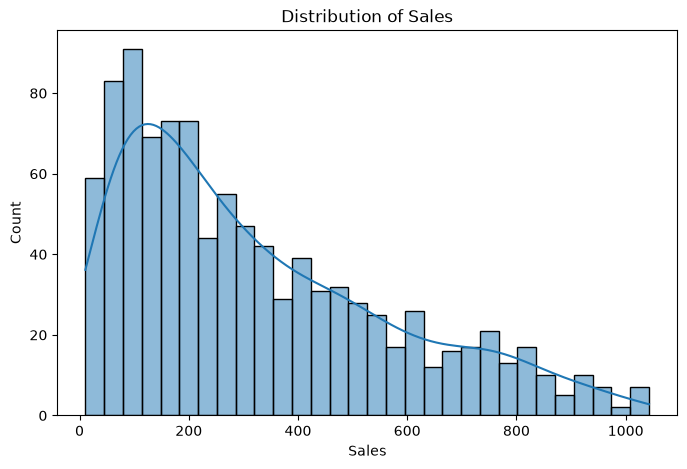

In [53]:
plt.figure(figsize=(8,5))

sns.histplot(df["sales"], bins=30, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Count")

plt.show()

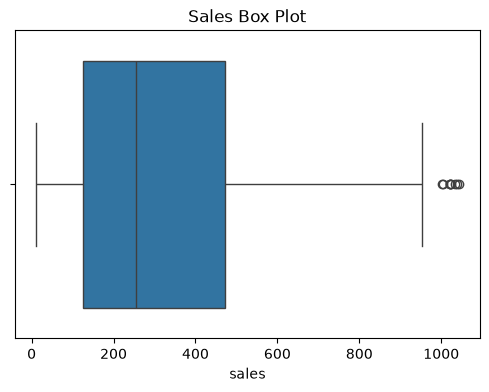

In [54]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["sales"])

plt.title("Sales Box Plot")

plt.show()

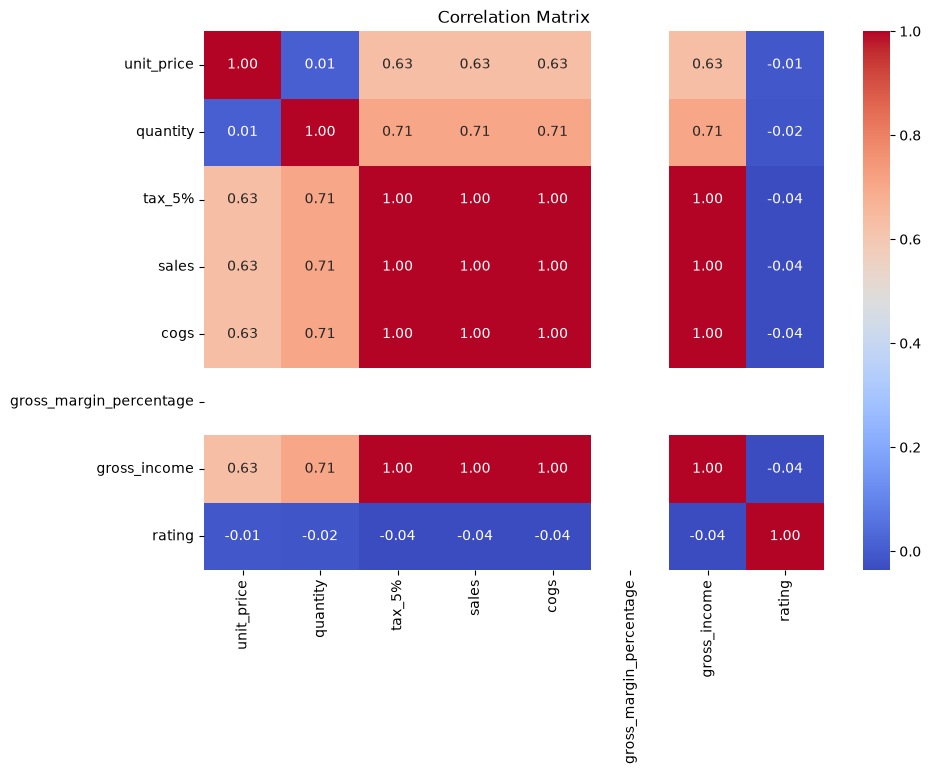

In [55]:
numeric_df = df.select_dtypes(include=["number"])

corr = numeric_df.corr()

plt.figure(figsize=(10,7))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Matrix")

plt.show()

In [56]:
male_sales = df[df["gender"] == "Male"]["sales"]

female_sales = df[df["gender"] == "Female"]["sales"]

t_stat, p_value = stats.ttest_ind(male_sales, female_sales)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -2.6736729611465173
P-value: 0.007625077102767302


In [57]:
if p_value < 0.05:
    print("Reject the Null Hypothesis")
    print("Sales differ significantly between Male and Female customers.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("No significant difference in sales between Male and Female customers.")

Reject the Null Hypothesis
Sales differ significantly between Male and Female customers.


# 📈 Time Series Analysis

## Objective

The objective of time series analysis is to examine how sales change over time. By aggregating daily sales and visualizing trends, we can identify patterns, seasonality, and overall business performance. Additionally, a forecasting model is developed to predict future sales.

In [58]:
daily_sales = df.groupby("date")["sales"].sum().reset_index()

daily_sales.head()

,date,sales
0,2019-01-01,4745.1810
1,2019-01-02,1945.5030
2,2019-01-03,2078.1285
3,2019-01-04,1623.6885
4,2019-01-05,3536.6835


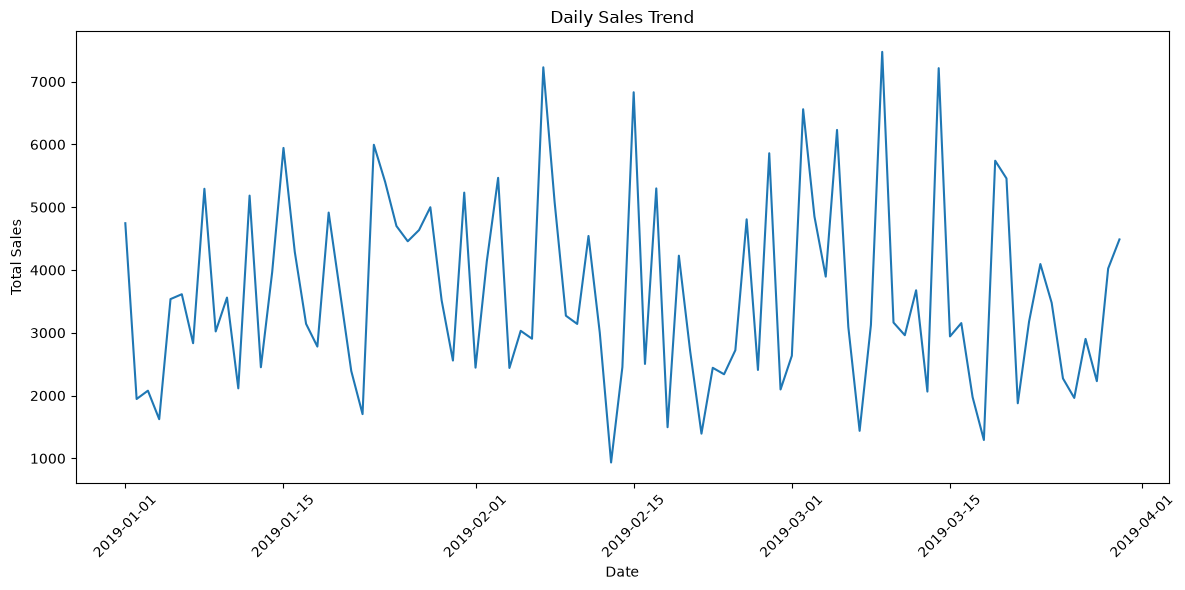

In [59]:
plt.figure(figsize=(12,6))

plt.plot(daily_sales["date"], daily_sales["sales"])

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

## Daily Sales Trend

The line chart illustrates the variation in total sales over time. This visualization helps identify trends, fluctuations, and periods of high or low sales activity.

In [60]:
monthly_sales = df.groupby(df["date"].dt.to_period("M"))["sales"].sum()

monthly_sales = monthly_sales.to_timestamp()

monthly_sales

date
2019-01-01    116291.868
2019-02-01     97219.374
2019-03-01    109455.507
Freq: MS, Name: sales, dtype: float64

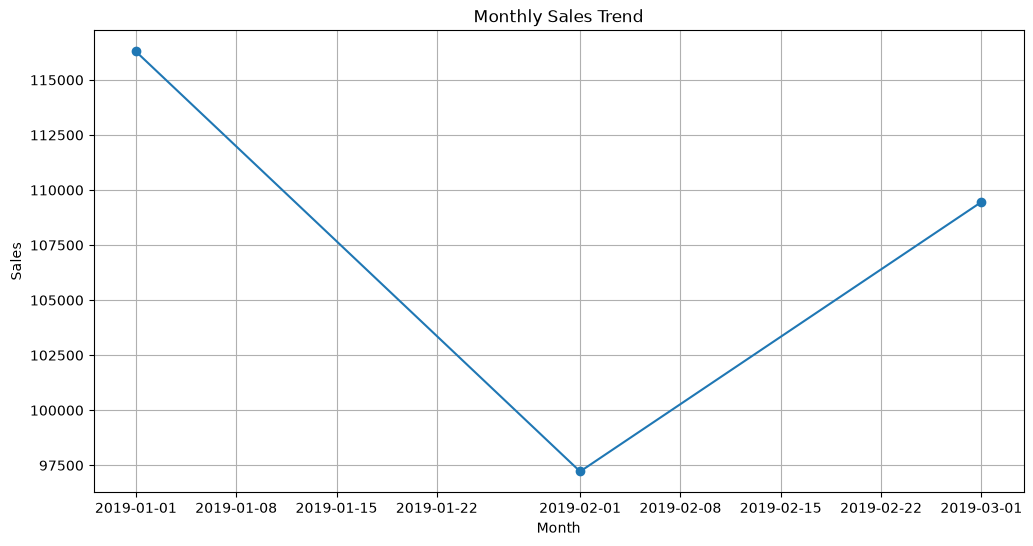

In [61]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index, monthly_sales.values, marker="o")

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

## Monthly Sales Trend

Monthly aggregation provides a clearer view of long-term sales performance by reducing daily fluctuations. This helps identify overall business growth or decline.

In [ ]:
model = ARIMA(monthly_sales, order=(1,1,1))

model_fit = model.fit()

forecast = model_fit.forecast(steps=3)

forecast

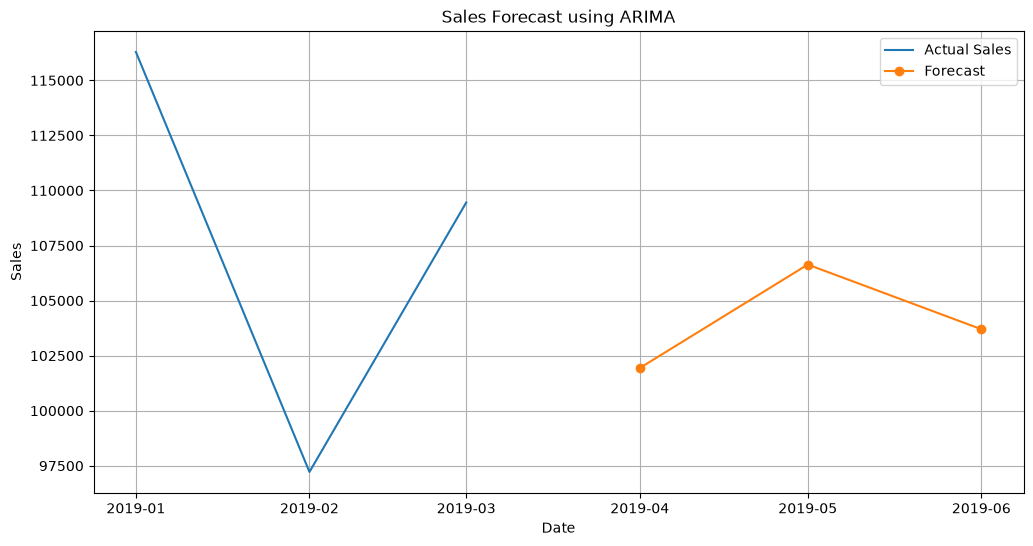

In [62]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index, monthly_sales.values, label="Actual Sales")

future_dates = pd.date_range(
    monthly_sales.index[-1] + pd.offsets.MonthBegin(1),
    periods=3,
    freq="MS"
)

plt.plot(future_dates, forecast, marker="o", label="Forecast")

plt.title("Sales Forecast using ARIMA")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.show()

# 👥 Customer Segmentation using K-Means Clustering

## Objective

The objective of customer segmentation is to group customers with similar purchasing behavior. K-Means clustering is an unsupervised machine learning algorithm that partitions data into clusters based on feature similarity. This helps businesses understand customer groups and design targeted marketing strategies.

In [63]:
features = df[["sales", "quantity", "rating"]]

features.head()

,sales,quantity,rating
0,548.9715,7,9.1
1,80.2200,5,9.6
2,340.5255,7,7.4
3,489.0480,8,8.4
4,634.3785,7,5.3


In [64]:
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

scaled_features[:5]

array([[ 0.91960685,  0.5099302 ,  1.23844341],
       [-0.98772956, -0.17453987,  1.52952681],
       [ 0.07144605,  0.5099302 ,  0.24875987],
       [ 0.67577985,  0.85216524,  0.83092666],
       [ 1.26712548,  0.5099302 , -0.97379039]])

In [65]:
inertia = []

for k in range(1,11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_features)
    inertia.append(model.inertia_)

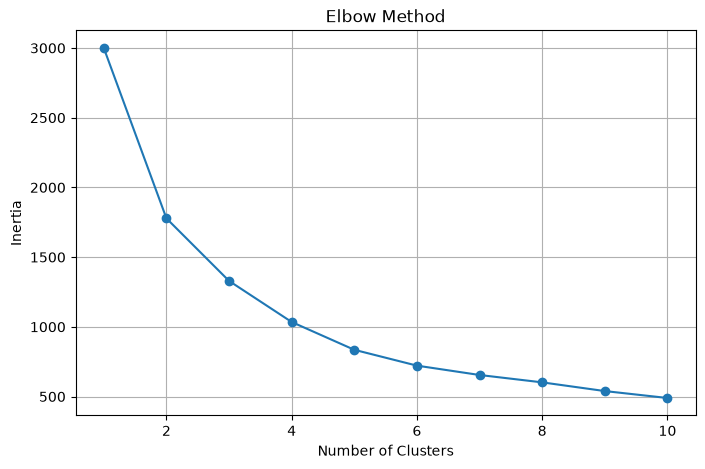

In [66]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker="o")

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.grid(True)

plt.show()

In [67]:
kmeans = KMeans(n_clusters=3, random_state=42)

df["Cluster"] = kmeans.fit_predict(scaled_features)

df.head()

,invoice_id,branch,city,customer_type,gender,product_line,unit_price,quantity,tax_5%,sales,date,time,payment,cogs,gross_margin_percentage,gross_income,rating,Cluster
0,750-67-8428,Alex,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,1:08:00 PM,Ewallet,522.83,4.761905,26.1415,9.1,2
1,226-31-3081,Giza,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00 AM,Cash,76.40,4.761905,3.8200,9.6,0
2,631-41-3108,Alex,Yangon,Normal,Female,Home and lifestyle,46.33,7,16.2155,340.5255,2019-03-03,1:23:00 PM,Credit card,324.31,4.761905,16.2155,7.4,2
3,123-19-1176,Alex,Yangon,Member,Female,Health and beauty,58.22,8,23.2880,489.0480,2019-01-27,8:33:00 PM,Ewallet,465.76,4.761905,23.2880,8.4,2
4,373-73-7910,Alex,Yangon,Member,Female,Sports and travel,86.31,7,30.2085,634.3785,2019-02-08,10:37:00 AM,Ewallet,604.17,4.761905,30.2085,5.3,2


In [68]:
df["Cluster"].value_counts()

Cluster
2    379
0    313
1    308
Name: count, dtype: int64

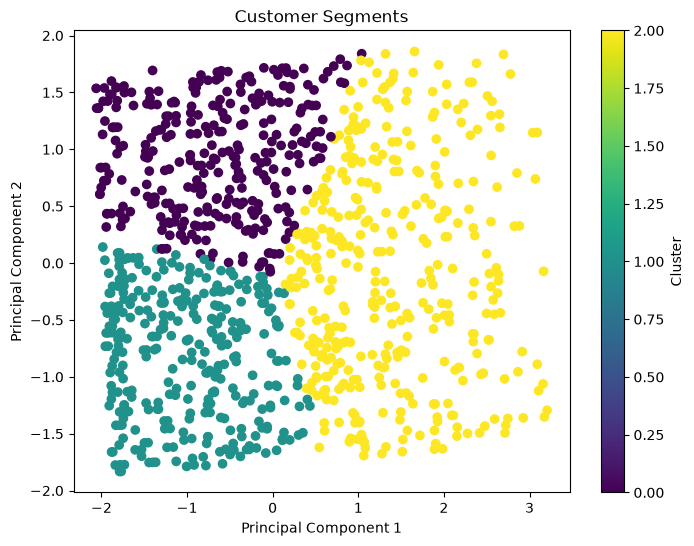

In [69]:
pca = PCA(n_components=2)

components = pca.fit_transform(scaled_features)

plt.figure(figsize=(8,6))

plt.scatter(
    components[:,0],
    components[:,1],
    c=df["Cluster"],
    cmap="viridis"
)

plt.title("Customer Segments")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [70]:
score = silhouette_score(scaled_features, df["Cluster"])

print("Silhouette Score:", score)

Silhouette Score: 0.31967461865620694


# 🤖 Predictive Modeling

## Objective

The objective of predictive modeling is to build machine learning models that can predict sales based on product attributes. In this section, Linear Regression and Decision Tree Regression models are developed and evaluated using performance metrics such as Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score.

In [71]:
X = df[["unit_price", "quantity", "rating"]]

y = df["sales"]

X.head()

,unit_price,quantity,rating
0,74.69,7,9.1
1,15.28,5,9.6
2,46.33,7,7.4
3,58.22,8,8.4
4,86.31,7,5.3


In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [73]:
tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [74]:
tree_predictions = tree.predict(X_test)

In [75]:
print("Decision Tree Performance")

print("MAE :", mean_absolute_error(y_test, tree_predictions))

print("RMSE :", np.sqrt(mean_squared_error(y_test, tree_predictions)))

print("R2 Score :", r2_score(y_test, tree_predictions))

Decision Tree Performance
MAE : 6.0355050000000015
RMSE : 11.223733100555277
R2 Score : 0.9980637241206021


In [76]:
lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](3,)","[ 5.79,58.22,-2.79]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](3,)","['unit_price','quantity','rating']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-302.2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,3
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(3)


In [77]:
lr_predictions = lr.predict(X_test)

In [78]:
print("Linear Regression Performance")

print("MAE :", mean_absolute_error(y_test, lr_predictions))

print("RMSE :", np.sqrt(mean_squared_error(y_test, lr_predictions)))

print("R2 Score :", r2_score(y_test, lr_predictions))

Linear Regression Performance
MAE : 58.41433946805875
RMSE : 78.73568835401649
R2 Score : 0.9047125222256869


In [79]:
tree = DecisionTreeRegressor(random_state=42)

tree.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [80]:
tree_predictions = tree.predict(X_test)

In [81]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "MAE": [
        mean_absolute_error(y_test, lr_predictions),
        mean_absolute_error(y_test, tree_predictions)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, lr_predictions)),
        np.sqrt(mean_squared_error(y_test, tree_predictions))
    ],
    "R2 Score": [
        r2_score(y_test, lr_predictions),
        r2_score(y_test, tree_predictions)
    ]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,58.414339,78.735688,0.904713
1,Decision Tree,6.035505,11.223733,0.998064


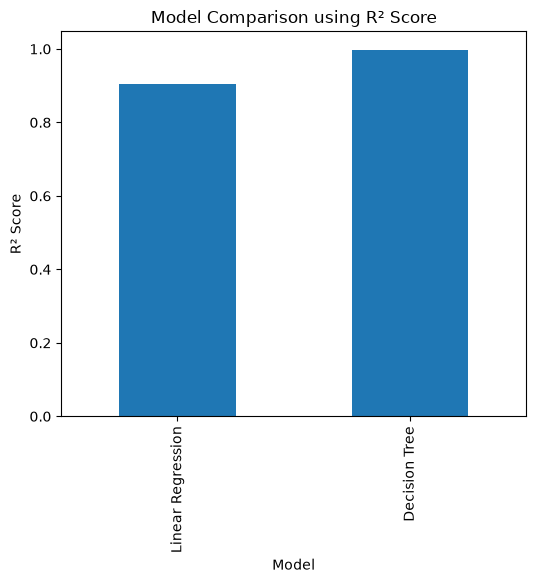

In [82]:
comparison.plot(
    x="Model",
    y="R2 Score",
    kind="bar",
    figsize=(6,5),
    legend=False
)

plt.title("Model Comparison using R² Score")

plt.ylabel("R² Score")

plt.show()

## Model Evaluation Summary

Both Linear Regression and Decision Tree Regression models were trained to predict sales. Their performance was evaluated using MAE, RMSE, and R² Score. The model with the higher R² Score and lower error values provides better predictive performance for this dataset.

# ✅ Conclusion

In this task, advanced analytics techniques were applied to the supermarket sales dataset. Descriptive statistics provided insights into the data distribution, while time series analysis revealed sales trends and future forecasts. Customer segmentation using K-Means identified distinct customer groups based on purchasing behavior. Finally, predictive models were developed to estimate sales, and their performance was evaluated using standard regression metrics.

These analyses demonstrate the application of statistical methods and machine learning techniques to extract meaningful insights and support data-driven business decisions.